In [ ]:
import numpy as np
import pandas as pd



In [ ]:
country = 'DEU'
if country == 'DEU' or True:
    fields_of_interest = {
    'Q275': {  # ANES — no direct analog; education added for cross-country comparability (ISCED 2011)
        "template": "My highest level of education is XXX.",
        "valmap": {
            0: 'early childhood education or no formal education',
            1: 'primary education',
            2: 'lower secondary education',
            3: 'upper secondary education',
            4: 'post-secondary non-tertiary education',
            5: 'short-cycle tertiary education',
            6: 'a bachelor\'s degree or equivalent',
            7: 'a master\'s degree or equivalent',
            8: 'a doctoral degree or equivalent',
        }
    },
    'Q288R': {  # WVS recoded household income (low/middle/high); preferred over raw 10-step Q288
        "template": "My household income is XXX.",
        "valmap": {
            1: 'low',
            2: 'middle',
            3: 'high',
        }
    },
    'Q200': {  # ANES V162174 — discuss politics with others
        "template": "XXX",
        "valmap": {
            1: 'I frequently discuss political matters with my friends.',
            2: 'I occasionally discuss political matters with my friends.',
            3: 'I never discuss political matters with my friends.'
        }
    },
    'Q240': {  # ANES V161126 — ideology (left–right self-placement, 1–10)
        "template": "On a left-right scale, I place myself XXX.",
        "valmap": {
            1: "on the far left",
            2: "on the left",
            3: "left of center",
            4: "slightly left of center",
            5: "at the center",
            6: "at the center",
            7: "slightly right of center",
            8: "right of center",
            9: "on the right",
            10: "on the far right"
        }
    },
    'Q171': {  # ANES V161244 — religious attendance
        "template": "I XXX.",
        "valmap": {
            1: "attend religious services more than once a week",
            2: "attend religious services once a week",
            3: "attend religious services once a month",
            4: "attend religious services only on special holy days",
            5: "attend religious services once a year",
            6: "attend religious services less than once a year",
            7: "never attend religious services"
        }
    },
    'Q262': {  # ANES V161267 — age
        "template": "I am XXX years old.",
        "valmap": {}
    },
    'Q260': {  # ANES V161342 — sex
        "template": "I am a XXX.",
        "valmap": {1: "man", 2: "woman"}
    },
    'Q199': {  # ANES V162256 — political interest
        "template": "I am XXX interested in politics.",
        "valmap": {1: "very", 2: "somewhat", 3: "not very", 4: "not at all"}
    }
    }



In [25]:
def compute_demographic_distribution(fields_of_interest, df: pd.DataFrame):
    """Compute empirical distributions for each field of interest."""
    distributions = {}
    for key in fields_of_interest.keys():
        value_counts = df[key].value_counts(normalize=True).to_dict()
        distributions[key] = value_counts
    return distributions

In [32]:
SEP=','
WVS_DEU = f'data/WVS_Wave_7_DEU.csv'
df = pd.read_csv(WVS_DEU, sep=SEP, encoding="latin-1", low_memory=False)
distributions_DEU = compute_demographic_distribution(fields_of_interest, df)

WVS_NLD = f'data/WVS_Wave_7_NLD.csv'
df = pd.read_csv(WVS_NLD, sep=SEP, encoding="latin-1", low_memory=False)
distributions_NLD = compute_demographic_distribution(fields_of_interest, df)


WVS_GBR = f'data/WVS_Wave_7_GBR.csv'
df = pd.read_csv(WVS_GBR, sep=SEP, encoding="latin-1", low_memory=False)
distributions_GBR = compute_demographic_distribution(fields_of_interest, df)

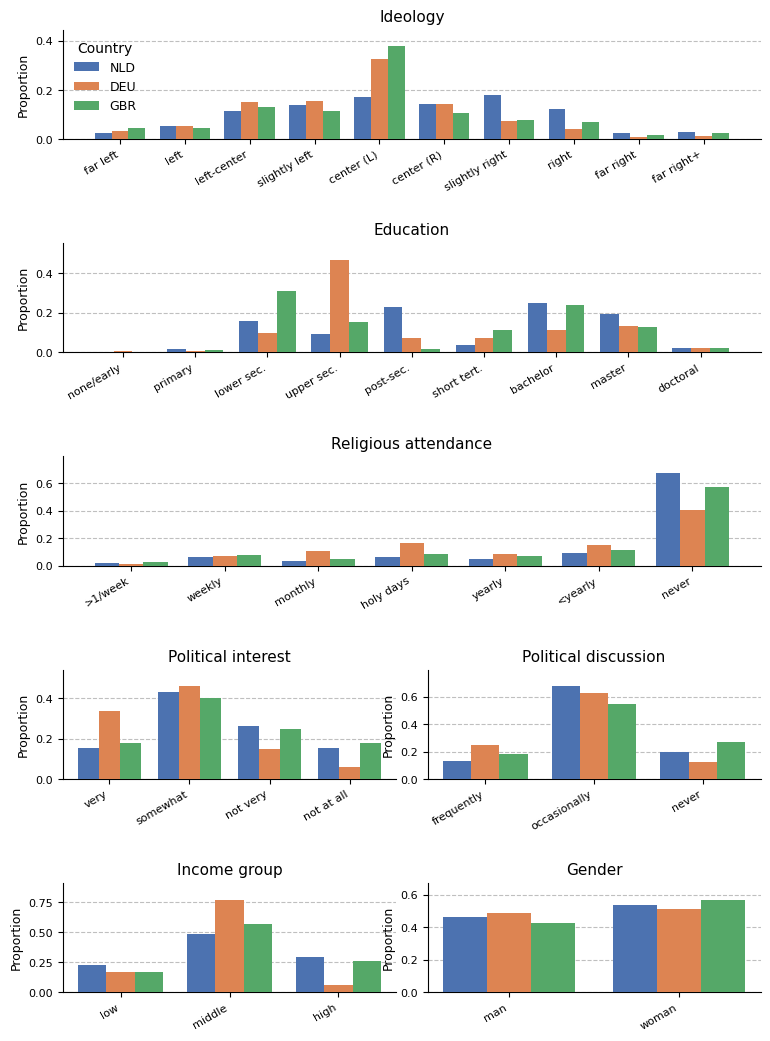

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
 
SHORT = {
    "Q240": {1:"far left",2:"left",3:"left-center",4:"slightly left",5:"center (L)",
             6:"center (R)",7:"slightly right",8:"right",9:"far right",10:"far right+"},
    "Q199": {1:"very",2:"somewhat",3:"not very",4:"not at all"},
    "Q260": {1:"man",2:"woman"},
    "Q275": {0:"none/early",1:"primary",2:"lower sec.",3:"upper sec.",4:"post-sec.",
             5:"short tert.",6:"bachelor",7:"master",8:"doctoral"},
    "Q288R": {1:"low",2:"middle",3:"high"},
    "Q200": {1:"frequently",2:"occasionally",3:"never"},
    "Q171": {1:">1/week",2:"weekly",3:"monthly",4:"holy days",5:"yearly",6:"<yearly",7:"never"},
}
TITLE = {"Q240":"Ideology","Q199":"Political interest","Q260":"Gender","Q275":"Education",
          "Q288R":"Income group","Q200":"Political discussion","Q171":"Religious attendance"}
dists = {"NLD": distributions_NLD, "DEU": distributions_DEU, "GBR": distributions_GBR}

COUNTRIES = ["NLD","DEU","GBR"]
COLOR = {"NLD":"#4C72B0","DEU":"#DD8452","GBR":"#55A868"}

# layout: each inner list is one row; one var = full width, multiple = split equally
LAYOUT = [
    ["Q240"],            # Ideology (10)            full width
    ["Q275"],            # Education (9)             full width
    ["Q171"],            # Religious attendance (7)  full width
    ["Q199","Q200"],     # Political interest (4) | Political discussion (3)
    ["Q288R","Q260"],    # Income (3)             | Gender (2)
]
NCOL = 6  # divisible by 1, 2, 3

def clean(d):  # drop negative codes, renormalize over substantive options
    d = {int(k):v for k,v in d.items() if float(k) >= 0}
    s = sum(d.values())
    return {k:v/s for k,v in d.items()} if s else d

def draw(ax, var, dists):
    codes = sorted(SHORT[var].keys())
    x = np.arange(len(codes)); w = 0.26; maxv = 0
    for i,c in enumerate(COUNTRIES):
        d = clean(dists[c].get(var, {}))
        vals = [d.get(code,0.0) for code in codes]
        maxv = max(maxv, max(vals) if vals else 0)
        ax.bar(x+(i-1)*w, vals, w, color=COLOR[c], label=c, zorder=3)
    ax.set_title(TITLE[var], fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([SHORT[var][c] for c in codes], rotation=30, ha="right", fontsize=8)
    ax.set_ylim(0, max(0.3, maxv*1.18)); ax.set_ylabel("Proportion", fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    # --- ANES-style: dashed y-grid behind bars, no top/right spine ---
    ax.grid(axis='y', linestyle='--', color='gray', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top','right']].set_visible(False)

def plot_grid(dists, fname):
    nrows = len(LAYOUT)
    fig = plt.figure(figsize=(9, 2.5*nrows))
    gs = gridspec.GridSpec(nrows, NCOL, figure=fig, hspace=0.95, wspace=0.35)
    first_ax = None
    for r,row in enumerate(LAYOUT):
        k = len(row); span = NCOL//k
        for j,var in enumerate(row):
            ax = fig.add_subplot(gs[r, j*span:(j+1)*span])
            draw(ax, var, dists)
            if first_ax is None: first_ax = ax
    h,l = first_ax.get_legend_handles_labels()
    first_ax.legend(h, l, title="Country", loc="upper left", frameon=False, fontsize=9)
    plt.savefig(fname, bbox_inches="tight", dpi=120)

plot_grid(dists, "wvs7_demographics.pdf")